# MCMC one parameter

In [7]:
import pymc3 as pm
import numpy as np
import theano.tensor as tt
import matplotlib.pyplot as plt
from ann_functions import import_data
from keras.models import load_model
from keras.initializers import glorot_uniform
import keras.backend as K
from keras.utils import custom_object_scope
import tensorflow as tf
import keras

In [ ]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Introduzione dati 

In [8]:
# cell 1                                                        
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[:, -1, 44,44]
# ADD NOISE
noise_stddev = np.mean(U_HF_test) * 0.01       # value?
noise = np.random.normal(0, noise_stddev, len(U_HF_test))
U_HF_test_selection = U_HF_test + noise


permutation = np.random.permutation(len(U_HF_test_selection))
n_HF = 15
U_HF_test_selection = U_HF_test_selection[permutation][0:n_HF]


In [9]:
# Definisci la tua funzione di attivazione personalizzata (in codice finale, dove tutto andrà da inizio a fine, non credo questa parte sarà più necessaria...)
def custom_activation(x):
    # Implementa la tua logica personalizzata qui
    return x + K.square(K.sin(x))

# Aggiungi la tua funzione di attivazione personalizzata al dizionario custom_objects
custom_objects = {'custom_activation': custom_activation, 'glorot_uniform': glorot_uniform()}

# Carica il modello utilizzando custom_objects
with custom_object_scope(custom_objects):
    keras_model1 = load_model("modelLF.h5")
    keras_model2 = load_model("modelLin.h5")
    keras_model3 = load_model("finalModel.h5")

Certamente, vediamo in dettaglio cosa rappresentano i grafici generati da pm.traceplot(trace):

Tracce delle Catene
Tracce delle Catene: I grafici principali mostrano le tracce delle catene per ciascun parametro del modello. Ogni curva rappresenta la sequenza di valori campionati dalla catena corrispondente. È importante che le tracce siano stabili e non mostrino pattern particolari come divergenze o oscillazioni anomale.

Divergenze: Sotto ogni traccia, potresti vedere una colonna chiamata "divergenze". Questo è utile per identificare eventuali problemi di divergenza nelle catene. Se vedi punti o segmenti rossi sotto le tracce, potrebbe indicare che il campionamento MCMC ha avuto difficoltà a esplorare alcune regioni dello spazio dei parametri.

Distribuzioni Marginali
Distribuzioni Marginali: I grafici lungo la diagonale mostrano le distribuzioni marginali dei parametri. Queste distribuzioni indicano la probabilità stimata di ogni valore del parametro. Dovresti cercare di vedere distribuzioni regolari e ben definite.

Traceplot 3D: Se hai più di un parametro, potresti vedere un grafico 3D delle tracce delle catene. Questo fornisce una visualizzazione delle relazioni tra i parametri.

Suggerimenti per Interpretare
Convergenza: Cerca tracce stabili. Se le tracce sembrano diventare stabili dopo un certo numero di passaggi, potrebbe indicare un periodo di "burn-in" iniziale da escludere dalle analisi.

Divergenze: Se ci sono divergenze, potrebbe indicare che il campionamento MCMC sta avendo difficoltà a esplorare lo spazio dei parametri. Questo potrebbe richiedere ulteriori regolazioni al modello.

Intervalli di Densità Più Elevata (HDI): Guarda gli HDI nelle distribuzioni marginali. Gli HDI rappresentano gli intervalli di credibilità e possono darti un'idea della precisione delle stime.

Questi sono punti generali, e l'interpretazione specifica può variare a seconda del tuo modello e dei tuoi dati.

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: divide by zero encountered in log
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: invalid value encountered in multiply
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, mu]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 40 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_4532\3567834781.py:18: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace)
Got error No model on context 

array([[<AxesSubplot:title={'center':'mu'}>,
        <AxesSubplot:title={'center':'mu'}>],
       [<AxesSubplot:title={'center':'sigma'}>,
        <AxesSubplot:title={'center':'sigma'}>]], dtype=object)

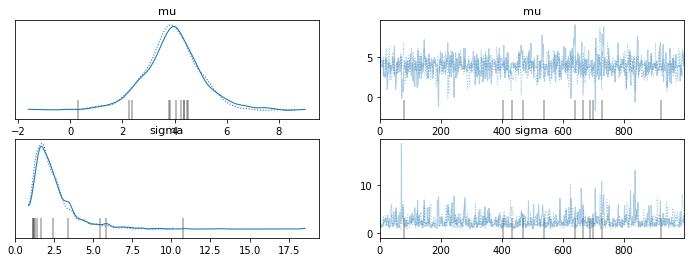

In [10]:
# dati
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 4, 5, 6])

# modello
with pm.Model() as model:
    # priori
    mu = pm.Normal('mu', mu=0, sd=10)
    sigma = pm.HalfNormal('sigma', sd=10)

    # likelihood
    obs = pm.Normal('obs', mu=mu, sd=sigma, observed=y)

    # sampling
    trace = pm.sample(1000)
    
pm.summary(trace).round(2)
pm.traceplot(trace)
# Estrai la traccia dei campioni per la variabile theta
#theta_samples = trace['theta']

In [11]:
print(trace)

<MultiTrace: 2 chains, 1000 iterations, 3 variables>


[[1.01037632]]
1/1 [==============================] - 0s 74ms/step


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, theta]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 61 seconds.
The acceptance probability does not match the target. It is 0.8928351125725057, but should be close to 0.8. Try to increase the number of tuning steps.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_4532\1460890212.py:32: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace)
Got error No model on context stack. trying 

Got error No model on context stack. trying to find log_likelihood in translation.


Stime della media di theta:
[[0.99399329]]

Deviazione standard di theta:
[[0.29249933]]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


AttributeError: 'Line2D' object has no property 'credible_interval'

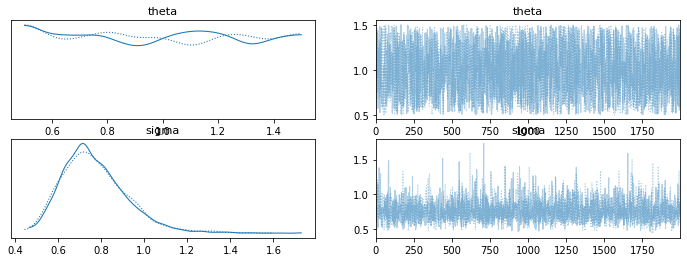

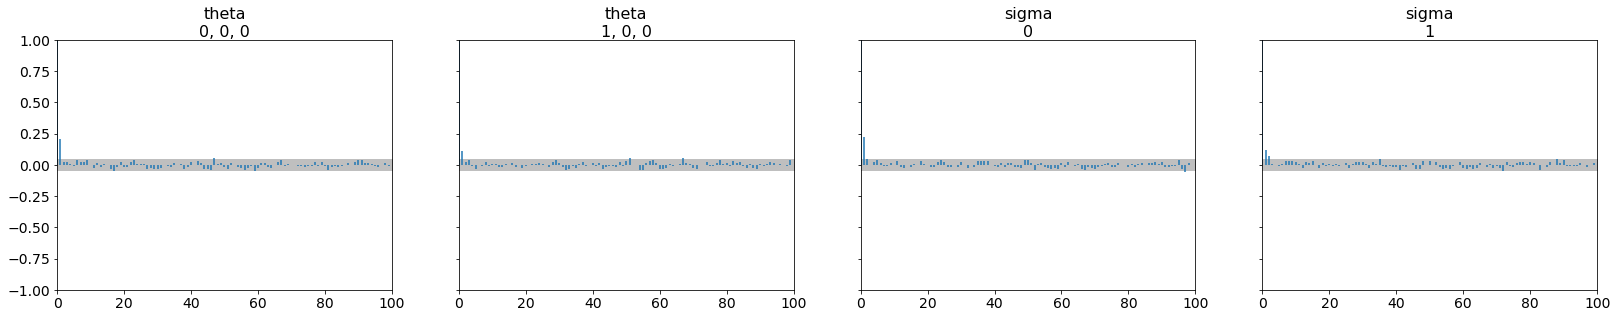

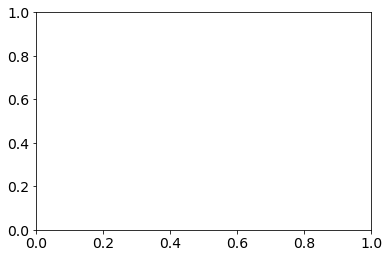

In [12]:
import arviz as az
import theano.tensor as tt

# Dati corretti o raffinati
data_true = U_HF_test_selection  # Inserisci i tuoi dati corretti

# Modello PyMC3
with pm.Model() as model:
    # Prior sui parametri del modello numerico approssimato
    theta = pm.Uniform('theta', lower=0.5, upper=1.5, shape=(1,1))  # Modifica shape in base ai tuoi parametri
    theta_0=theta.random()
    print(theta_0)
    # Modello numerico approssimato
    out1=keras_model1.predict(theta_0)
    in2 = np.hstack((theta_0, out1))
    out2=keras_model2.predict(in2)
    in3 = np.hstack((in2, out2))
    approx_model_output=keras_model3.predict(in3)
    #approx_model_output = custom_numerical_model(theta)  # Sostituisci con il tuo modello numerico

    # Likelihood basato sui dati osservati
    likelihood= pm.Normal('likelihood', mu=approx_model_output, sd=pm.HalfNormal('sigma', sd=1), observed=data_true)

    # Likelihood basato sui dati corretti
    #likelihood_true = pm.Normal('likelihood_true', mu=approx_model_output, sd=pm.HalfNormal('sigma', sd=1), observed=data_true)

    # Campionamento MCMC
    trace = pm.sample(2000, tune=1000, cores=1)

# Analisi dei risultati
pm.summary(trace).round(2)
pm.traceplot(trace)
# Estrai la traccia dei campioni per la variabile theta
theta_samples = trace['theta']

# Calcola la stima della media e la deviazione standard per ogni parametro
estimated_theta_mean = theta_samples.mean(axis=0)
estimated_theta_std = theta_samples.std(axis=0)
pm.autocorrplot(trace)

ppc = pm.sample_posterior_predictive(trace, samples=500, model=model)

# Stampa le stime
print("Stime della media di theta:")
print(estimated_theta_mean)
print("\nDeviazione standard di theta:")
print(estimated_theta_std)
az.plot_posterior(trace, var_names=['theta'], credible_interval=0.95)

[[1.23469388]]
1/1 [==============================] - 0s 146ms/step


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [sigma]
>Metropolis: [theta]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
The number of effective samples is smaller than 25% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_4532\2112568140.py:39: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace)
Got error No model on context stack. trying to find log_likelihood in translation.


             mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
theta[0, 0]  0.99  0.52    0.07     2.02       0.02     0.01     807.0   
sigma        1.23  0.49    0.47     2.16       0.02     0.01    1032.0   

             ess_tail  r_hat  
theta[0, 0]    1008.0    1.0  
sigma          1180.0    1.0  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


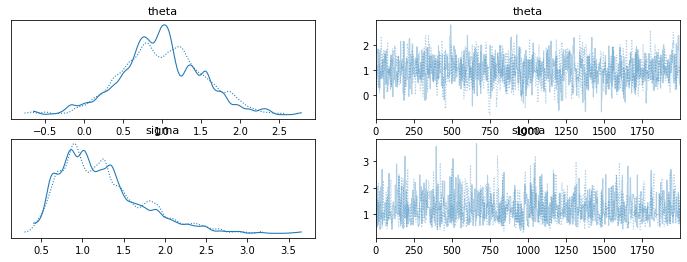

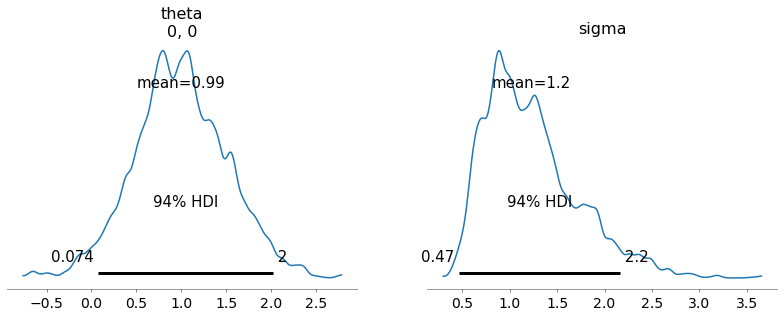

Stime della media di theta:
[[0.98928711]]

Deviazione standard di theta:
[[0.51626769]]


NameError: name 'sampler_stats' is not defined

In [14]:
import arviz as az

# Dati corretti o raffinati
data_true = U_HF_test_selection  # Inserisci i tuoi dati corretti
theta_lower = 0.5
theta_upper = 1.5

mu_prior = (theta_lower + theta_upper) / 2  # Media nel centro del range
sigma_prior = (theta_upper - theta_lower) / 2

reaction_nn=reaction_HF_test[permutation][2:3]
print(reaction_nn)
data_true=U_HF_test_selection[2:3]
# Modello PyMC3
with pm.Model() as model:
    # Prior sui parametri del modello numerico approssimato
    theta = pm.Normal('theta', mu=mu_prior, sd=sigma_prior,shape=(1,1))
    #theta = pm.Uniform('theta', lower=0.5, upper=1.5, shape=(1,1))  # Modifica shape in base ai tuoi parametri
    #theta_0=theta.random()
    # Modello numerico approssimato
    out1=keras_model1.predict(reaction_nn)
    in2 = np.hstack((reaction_nn, out1))
    out2=keras_model2.predict(in2)
    in3 = np.hstack((in2, out2))
    approx_model_output=keras_model3.predict(in3)
    #approx_model_output = custom_numerical_model(theta)  # Sostituisci con il tuo modello numerico

    # Likelihood basato sui dati osservati
    likelihood= pm.Normal('likelihood', mu=approx_model_output, sd=pm.HalfNormal('sigma', sd=1), observed=data_true)

    # Likelihood basato sui dati corretti
    #likelihood_true = pm.Normal('likelihood_true', mu=approx_model_output, sd=pm.HalfNormal('sigma', sd=1), observed=data_true)

    # Campionamento MCMC
    trace = pm.sample(2000, tune=1000, cores=1,step=pm.Metropolis())

# Analisi dei risultati
print(pm.summary(trace).round(2))
pm.traceplot(trace)
# Estrai la traccia dei campioni per la variabile theta
theta_samples = trace['theta']

# Calcola la stima della media e la deviazione standard per ogni parametro
estimated_theta_mean = theta_samples.mean(axis=0)
estimated_theta_std = theta_samples.std(axis=0)

pm.plot_posterior(trace)
plt.show()

# Stampa le stime
print("Stime della media di theta:")
print(estimated_theta_mean)
print("\nDeviazione standard di theta:")
print(estimated_theta_std)

# Recupera le statistiche del sampler
#sampler_stats = trace.get_sampler_stats("metropolis")

# Estrai il numero di acceptance e rejection
acceptance_rates = sampler_stats[:, 0]  # Colonna 0: acceptance
rejection_rates = 1 - acceptance_rates
pm.autocorrplot(trace)

ppc = pm.sample_posterior_predictive(trace, samples=500, model=model)
# Plot acceptance e rejection
plt.plot(acceptance_rates, label="Acceptance Rate")
plt.plot(rejection_rates, label="Rejection Rate")
plt.xlabel("Iteration")
plt.ylabel("Rate")
plt.legend()
plt.show()
#az.plot_posterior(trace, var_names=['theta'], credible_interval=0.95)

In [55]:
# Estrai i campioni per la variabile theta
theta_samples = trace['theta']

# Calcola il tasso di accettazione
acceptance_rate = np.mean(trace['theta'][1:] != trace['theta'][:-1])

# Stampa il risultato
print(f"Tasso di accettazione: {acceptance_rate}")

Tasso di accettazione: 0.46136534133533386


In [56]:
print(reaction_nn)

[[1.47959184]]


In [59]:
print(trace['theta'][-10:-1])

[[[ 0.04716139]]

 [[ 0.11685084]]

 [[-0.38227302]]

 [[-0.38227302]]

 [[ 0.51614731]]

 [[ 0.51614731]]

 [[ 0.51614731]]

 [[ 1.72330536]]

 [[ 1.72330536]]]


Accettazioni: 6563.424281368185
Totale iterazioni: 4000
Tasso di accettazione: 1.6408560703420463


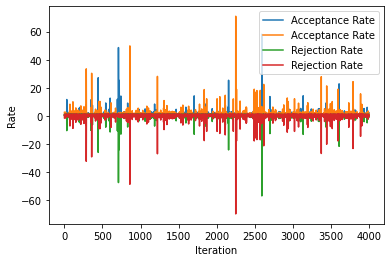

In [37]:
# Estrai il numero di acceptance e rejection
acceptance_rates = trace.get_sampler_stats("accept")  # Ogni 20 iterazioni
rejection_rates = 1 - acceptance_rates
# Calcola il numero totale di accettazioni
total_accepted = np.sum(acceptance_rates)
total_iterations = len(acceptance_rates)

# Calcola il tasso di accettazione
acceptance_rate = total_accepted / total_iterations

# Stampa il risultato
print(f"Accettazioni: {total_accepted}")
print(f"Totale iterazioni: {total_iterations}")
print(f"Tasso di accettazione: {acceptance_rate}")
# Plot acceptance e rejection
plt.plot(acceptance_rates, label="Acceptance Rate")
plt.plot(rejection_rates, label="Rejection Rate")
plt.xlabel("Iteration")
plt.ylabel("Rate")
plt.legend()
plt.show()

In [42]:
print(acceptance_rates)

[[0.99369907 2.38626881]
 [0.91189164 0.9752664 ]
 [1.01175412 0.26767405]
 ...
 [2.48160291 1.81082624]
 [1.34111649 0.36079629]
 [1.24591234 0.45024693]]


In [25]:
print(approx_model_output)
print(data_true)

[[ 0.85828197]
 [ 0.46720624]
 [-0.05661122]]
[ 0.75500431 -0.54002059 -0.29532141]


[[0.61089082]]
[[0.8142119]]


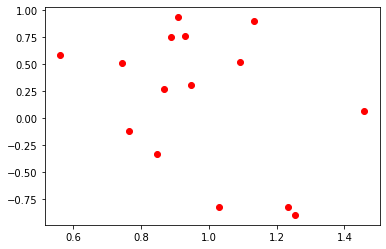

In [8]:
plt.figure()
plt.plot(reaction_HF_test[permutation, 0][0:n_HF], U_HF_test, "ro", linewidth=1.5, label="HF model")
print(theta_0)
print(approx_model_output)

Certamente, cercherò di spiegare meglio quella frase. In PyMC3, quando crei una variabile casuale che rappresenta la likelihood del modello, usi il parametro observed per collegare questa variabile ai dati osservati.

Nel contesto di una distribuzione normale, come nell'esempio precedente, abbiamo la seguente struttura:

python
Copy code
likelihood = pm.Normal('likelihood', mu=mu, sd=sd, observed=D)
Dove:

'likelihood' è il nome della variabile casuale di likelihood.
mu e sd sono i parametri del modello (la media e la deviazione standard della distribuzione normale).
D è la variabile che rappresenta i dati osservati.
La presenza di observed=D in questa definizione è cruciale. Ciò significa che stiamo dicendo a PyMC3 che questa variabile casuale di likelihood è "osservata" e dovrebbe essere trattata come i dati reali che abbiamo a disposizione.

Quando esegui l'ottimizzazione o il campionamento MCMC, PyMC3 utilizza l'informazione fornita da questa variabile likelihood osservata per valutare la probabilità dei diversi set di parametri del modello. In pratica, stiamo dicendo a PyMC3: "Questi sono i dati che abbiamo osservato, e vogliamo trovare i valori dei parametri che massimizzano la probabilità di ottenere questi dati."

La variabile likelihood diventa quindi parte integrante del processo di stima dei parametri del modello, in quanto influisce sulla generazione di nuovi campioni durante il campionamento MCMC. La presenza di observed=D consente a PyMC3 di confrontare la variabile casuale likelihood con i dati osservati D durante il processo di inferenza, aiutando a determinare quali valori dei parametri sono più coerenti con i dati

[[0.93269711]]
1/1 [==============================] - 0s 52ms/step


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
Metropolis: [reaction]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 12 seconds.
The number of effective samples is smaller than 25% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_32\1427328431.py:32: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace)
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Py

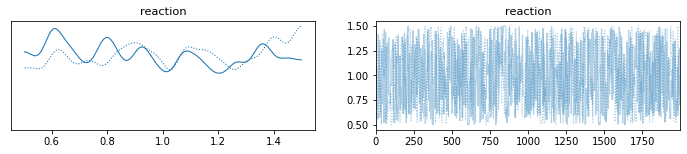

Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.


                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
reaction[0, 0]  1.001  0.293   0.568      1.5       0.01    0.007     676.0   

                ess_tail  r_hat  
reaction[0, 0]     811.0    1.0  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


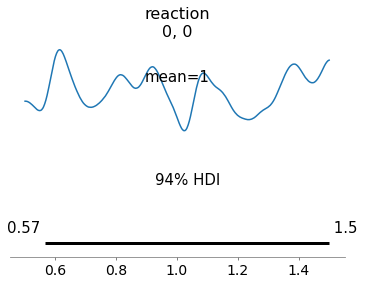

In [28]:
#Cell_3
with pm.Model() as model:
    #mu_0 = np.random.uniform(0,1, size=(U_HF_test.shape[0],3))
    #mu_0= pm.Uniform('reaction', lower=0, upper=1, shape=(U_HF_test.shape[0], 1))
    mu_0= pm.Uniform('reaction', lower=0.5, upper=1.5, shape=(1, 1))
    
    mu_0_array=mu_0.random()
    print(mu_0_array)
        # Priori
    #slope = pm.Normal('slope', mu=0, sd=10)
    #intercept = pm.Normal('intercept', mu=0, sd=10)
    out1=keras_model1.predict(mu_0_array)
    in2 = np.hstack((mu_0_array, out1))
    out2=keras_model2.predict(in2)
    in3 = np.hstack((in2, out2))
    U_MF=keras_model3.predict(in3)

    # Likelihood
    likelihood = pm.Normal('likelihood', mu=U_MF, sd=5, observed=U_HF_test)

    # Creation of Metropolis object
    step = pm.Metropolis()

    # Campionamento MCMC
    #trace = pm.sample(2000, tune=1000, cores=1, step=step) # tune := burn-in, uses Metropolis
    trace = pm.sample(2000, tune=1000, cores=1, step=step) # tune := burn-in, uses Metropolis

# analysis of the summary, resume
pm.summary(trace).round(2)   

# Plot
pm.traceplot(trace)
plt.show()

# Statistiche di interesse
print(pm.summary(trace))

# Plot della distribuzione a posteriori di eta
pm.plot_posterior(trace)
plt.show()

In [ ]:
with pm.Model() as model:
    mu_0= pm.Uniform('reaction', lower=0.5, upper=1.5, shape=(1, 1))
    
    mu_0_array=mu_0.random()

In [ ]:
print(mu_0_array)

In [ ]:
with pm.Model() as model

In [ ]:
#Cell_3
with pm.Model() as model:
    #mu_0 = np.random.uniform(0,1, size=(U_HF_test.shape[0],3))
    #mu_0= pm.Uniform('reaction', lower=0, upper=1, shape=(U_HF_test.shape[0], 1))
    mu_0= pm.Uniform('reaction', lower=0.5, upper=1.5, shape=(1, 1))
    
    mu_0_array=mu_0.random()
        # Priori
    #slope = pm.Normal('slope', mu=0, sd=10)
    #intercept = pm.Normal('intercept', mu=0, sd=10)
    out1=keras_model1.predict(mu_0_array)
    in2 = np.hstack((mu_0_array, out1))
    out2=keras_model2.predict(in2)
    in3 = np.hstack((in2, out2))
    U_MF=keras_model3.predict(in3)

    # Likelihood
    likelihood = pm.Normal('likelihood', mu=U_MF, sd=5, observed=U_HF_test)

    # Creation of Metropolis object
    step = pm.Metropolis()

    # Campionamento MCMC
    #trace = pm.sample(2000, tune=1000, cores=1, step=step) # tune := burn-in, uses Metropolis
    trace = pm.sample(2000, tune=1000, cores=1, step=step) # tune := burn-in, uses Metropolis

# analysis of the summary, resume
pm.summary(trace).round(2)   

# Plot
pm.traceplot(trace)
plt.show()

# Statistiche di interesse
print(pm.summary(trace))

# Plot della distribuzione a posteriori di eta
pm.plot_posterior(trace)
plt.show()

In [ ]:
print(mu_0_array)

In [ ]:
print(reaction_HF_test)

Certamente, la valutazione dei parametri ottenuti da un campionamento MCMC è cruciale per comprendere la bontà del tuo modello bayesiano. Ecco alcune considerazioni chiave per valutare i parametri e la convergenza del modello:

Media e Deviazione Standard:

Mean: La media rappresenta la stima puntiforme del parametro. Un valore lontano da zero potrebbe indicare un effetto significativo.
SD (Deviazione Standard): Indica la variabilità dei valori campionati attorno alla media. Una SD troppo alta potrebbe suggerire una bassa precisione nella stima.
Intervallo di Credibilità (HDI):

HDI 2.5% e HDI 97.5%: Gli estremi dell'intervallo di credibilità al 95%. Un intervallo più stretto indica maggiore precisione e confidenza nella stima.
Convergenza:

R-hat (Gelman-Rubin): Un valore di R-hat vicino a 1 indica convergenza. Controlla che R-hat sia vicino a 1 per tutti i parametri.
Ess (Numero Effettivo di Campionamenti): Maggiore è il numero effettivo di campionamenti, meglio è per valutare la convergenza. Un numero basso potrebbe indicare problemi di convergenza.
Traceplot:

Traccia della Catena: Esamina la traccia di ciascuna catena per vedere se mostra una convergenza stabile. Se le catene mostrano oscillazioni o non convergono, potrebbe essere necessario regolare i parametri del campionamento.
Divergenze:

Divergenze: Se ci sono divergenze, potrebbe essere necessario regolare i parametri del campionamento. Divergenze possono indicare che il sampler ha difficoltà a esplorare lo spazio dei parametri.
Grafici di Diagnosi Aggiuntivi:

Grafici specifici del dominio: A seconda del tuo modello, potrebbero essere utili altri grafici di diagnosi specifici del dominio. Ad esempio, nel caso di modelli lineari, potresti esaminare i residui.
Validazione Incrociata (Cross-Validation):

Previsioni su dati nuovi: Utilizza il modello addestrato per fare previsioni su dati nuovi o di convalida. Valuta la bontà delle previsioni confrontandole con i dati osservati.
Sensibilità ai Priori:

Sensibilità ai Priori: Modifica i priori per vedere come influenzano i risultati. Una forte dipendenza dai priori potrebbe indicare che il modello non è sufficientemente informativo o che è sensibile alle specifiche scelte dei priori.

In [ ]:
# Calcola l'effective sample size (ess)
ess = az.ess(trace)

asymptotic_var = np.var(trace['reaction']) / ess.mean()

print("Asymptotic Variance:", asymptotic_var)

L'asymptotic variance è una misura della precisione del tuo stimatore. Un valore più basso indica una maggiore precisione, mentre un valore più alto indica una minore precisione. In generale, vorresti che l'asymptotic variance sia il più bassa possibile.

Per capire se il valore dell'asymptotic variance è "buono" o "cattivo", puoi fare le seguenti considerazioni:

Basso valore: Un valore basso dell'asymptotic variance indica che il tuo stimatore ha una buona precisione e che il campionamento MCMC ha convergenza sufficiente alla distribuzione di probabilità desiderata. Questo è un risultato positivo.

Alto valore: Un valore alto dell'asymptotic variance suggerisce che il tuo stimatore potrebbe avere una precisione inferiore. Potrebbe indicare che il campionamento MCMC non ha convergenza sufficiente o che il modello potrebbe richiedere ulteriori iterazioni o regolazioni dei parametri.

Tuttavia, il giudizio sulla bontà dell'asymptotic variance dipende anche dal contesto specifico del tuo problema e dalla precisione richiesta. Non c'è un valore assoluto che sia considerato "buono" o "cattivo". È utile confrontare i risultati con le aspettative del tuo problema e con valori ottenuti in esperimenti simili.

Inoltre, puoi considerare altri indicatori di convergenza del campionamento MCMC, come il diagnostic R-hat e il visualizzare i tracciati delle catene MCMC per valutare la convergenza visivamente. Se questi indicatori suggeriscono una convergenza insufficiente, potresti dover esaminare ulteriormente e migliorare il tuo modello o il processo di campionamento

In [ ]:
print(mu_0_array)

In [ ]:
# analysis of the summary, resume
pm.summary(trace).round(2)   


In [ ]:
print(trace[0].keys())
print(trace[0]['reaction_interval__'])

print(trace[0][0])

In [ ]:
# Plot
pm.traceplot(trace[:,0])
plt.show()

# Statistiche di interesse
print(pm.summary(trace))

In [ ]:
# Creazione di un tensore simbolico
keras_input = tt.matrix('keras_input')

with pm.Model() as model:
    mu_0 = pm.Uniform('reaction', lower=0, upper=1, shape=(U_HF_test.shape[0], 3))

    # Utilizzo di theano.function per valutare il modello Keras con mu_0 come input
    U_MF = theano.function([keras_input], keras_model.predict(keras_input))(mu_0)

    # Likelihood
    likelihood = pm.Normal('likelihood', mu=U_MF, sd=2, observed=U_HF_test)

    # Creazione di Metropolis
    step = pm.Metropolis()

    # Campionamento MCMC
    trace = pm.sample(2000, tune=1000, cores=1, step=step)